In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Библиотеки загружены, папка для графиков готова.")

Библиотеки загружены, папка для графиков готова.


In [3]:
import sys
from pathlib import Path
project_root = Path.cwd().parent 
sys.path.insert(0, str(project_root))
from config import IEEE_TRANSACTION_PATH, IEEE_IDENTITY_PATH

trans = pd.read_csv(IEEE_TRANSACTION_PATH)
identity = pd.read_csv(IEEE_IDENTITY_PATH)

df = trans.merge(identity, on="TransactionID", how="left")
print(f"Размер датасета: {df.shape}")
print(f"Колонок: {df.columns.tolist()[:10]}...") 

Размер датасета: (590540, 434)
Колонок: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5']...


Распределение классов:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


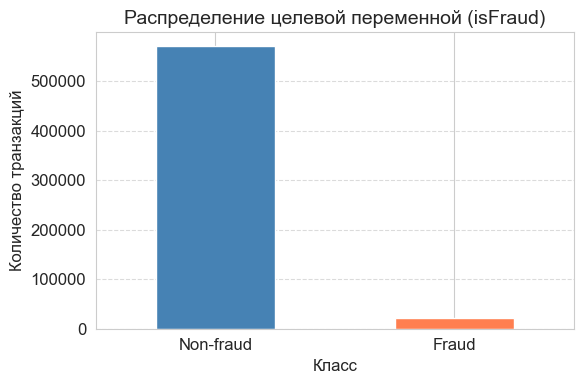

Доля фрода: 0.0350 (20663 транзакций)


In [4]:
target = "isFraud"
print("Распределение классов:")
print(df[target].value_counts(normalize=True))

plt.figure(figsize=(6,4))
df[target].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title("Распределение целевой переменной (isFraud)", fontsize=14)
plt.xlabel("Класс")
plt.ylabel("Количество транзакций")
plt.xticks([0,1], ['Non-fraud', 'Fraud'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_imbalance.png", dpi=150)
plt.show()

print(f"Доля фрода: {df[target].mean():.4f} ({df[target].sum()} транзакций)")

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/3817791128.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_missing["missing_percent"], y=top_missing.index, palette="viridis")


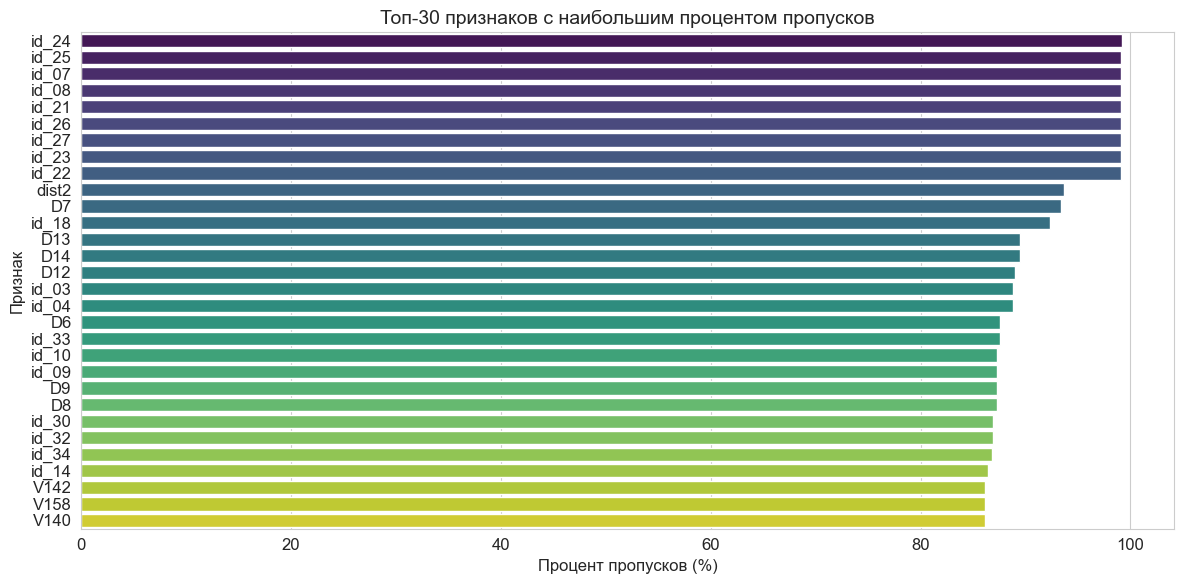

Всего колонок с пропусками: 414
Колонок с >80% пропусков: 74


In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_perc = (missing / len(df)) * 100
missing_df = pd.DataFrame({"missing_count": missing, "missing_percent": missing_perc})
missing_df = missing_df[missing_df["missing_count"] > 0]

top_missing = missing_df.head(30)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_missing["missing_percent"], y=top_missing.index, palette="viridis")
plt.title("Топ-30 признаков с наибольшим процентом пропусков", fontsize=14)
plt.xlabel("Процент пропусков (%)")
plt.ylabel("Признак")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "missing_values_top30.png", dpi=150)
plt.show()

print(f"Всего колонок с пропусками: {len(missing_df)}")
print(f"Колонок с >80% пропусков: {(missing_df['missing_percent'] > 80).sum()}")

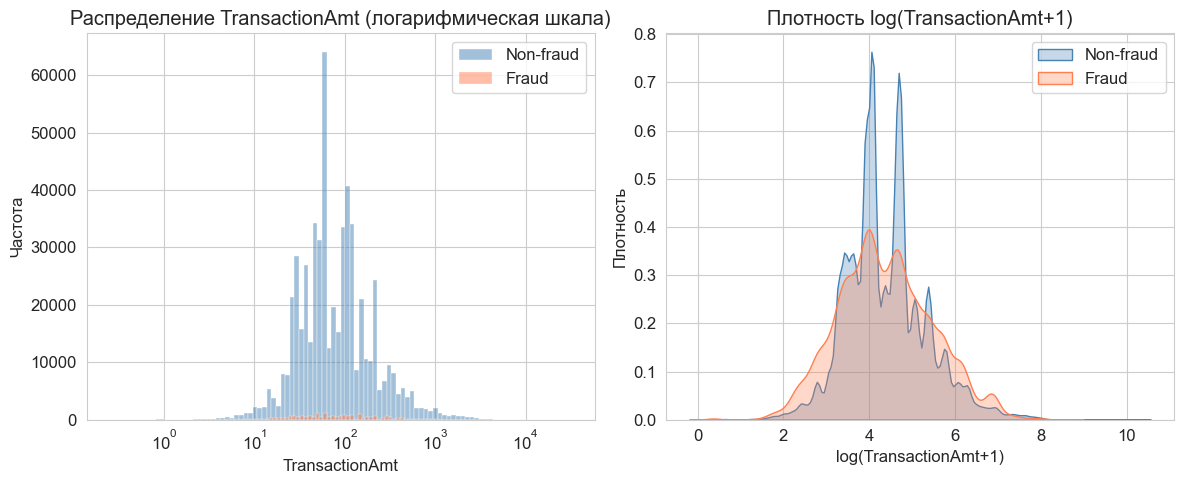

Статистики TransactionAmt по классам:
            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [6]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[df[target]==0]["TransactionAmt"], bins=100, color='steelblue', label='Non-fraud', alpha=0.5, log_scale=True)
sns.histplot(df[df[target]==1]["TransactionAmt"], bins=100, color='coral', label='Fraud', alpha=0.5, log_scale=True)
plt.title("Распределение TransactionAmt (логарифмическая шкала)")
plt.xlabel("TransactionAmt")
plt.ylabel("Частота")
plt.legend()

plt.subplot(1,2,2)
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
sns.kdeplot(df[df[target]==0]["TransactionAmt_log"], color='steelblue', label='Non-fraud', fill=True, alpha=0.3)
sns.kdeplot(df[df[target]==1]["TransactionAmt_log"], color='coral', label='Fraud', fill=True, alpha=0.3)
plt.title("Плотность log(TransactionAmt+1)")
plt.xlabel("log(TransactionAmt+1)")
plt.ylabel("Плотность")
plt.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "transaction_amount_distribution.png", dpi=150)
plt.show()

print("Статистики TransactionAmt по классам:")
print(df.groupby(target)["TransactionAmt"].describe())

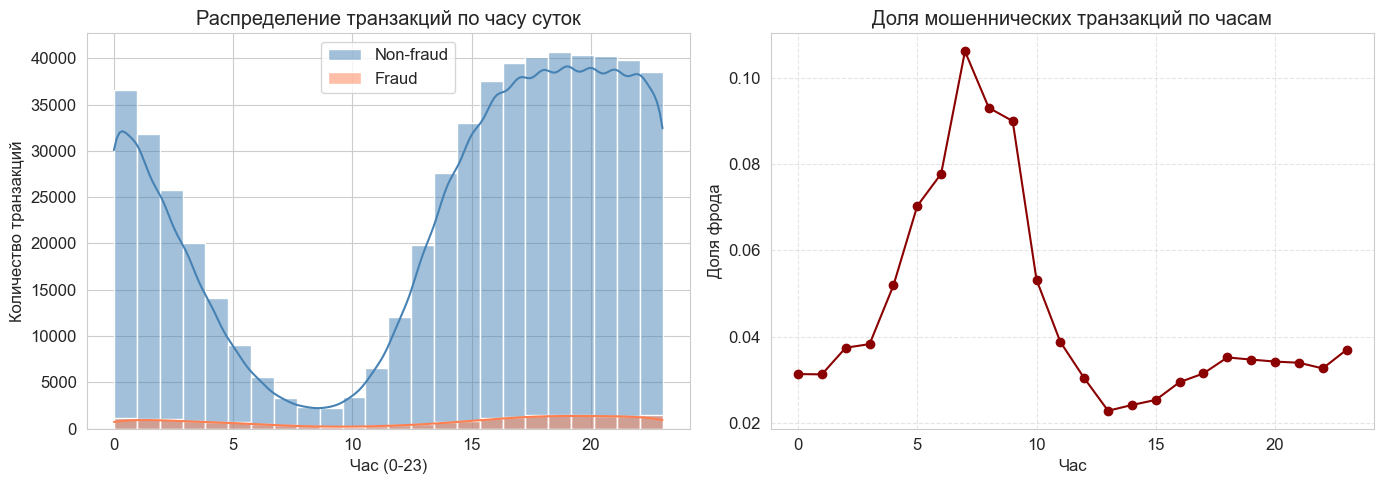

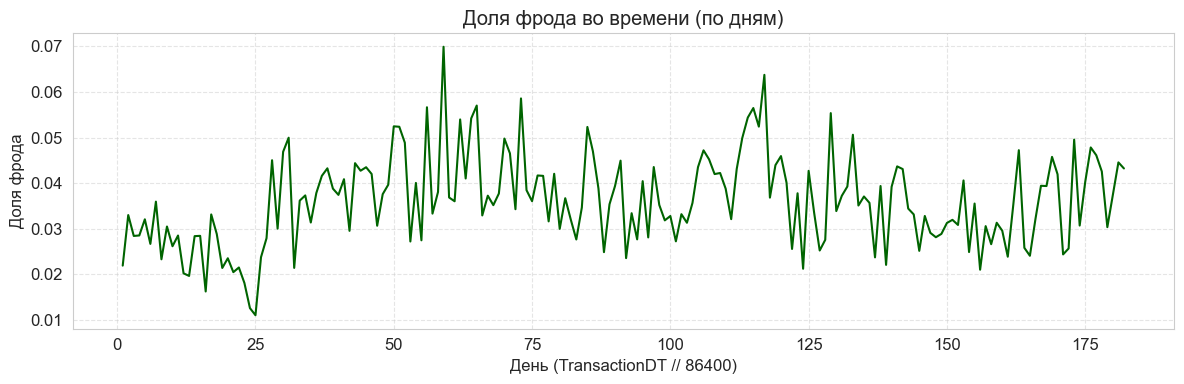

In [7]:
# TransactionDT — относительное время в секундах
# Добавим человеко-читаемые признаки
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = df['TransactionDT'] // (24*3600)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df[df[target]==0]["hour"], bins=24, color='steelblue', label='Non-fraud', alpha=0.5, kde=True)
sns.histplot(df[df[target]==1]["hour"], bins=24, color='coral', label='Fraud', alpha=0.5, kde=True)
plt.title("Распределение транзакций по часу суток")
plt.xlabel("Час (0-23)")
plt.ylabel("Количество транзакций")
plt.legend()

plt.subplot(1,2,2)
# Доля фрода по часам
fraud_by_hour = df.groupby('hour')[target].mean()
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='darkred')
plt.title("Доля мошеннических транзакций по часам")
plt.xlabel("Час")
plt.ylabel("Доля фрода")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "temporal_patterns_hour.png", dpi=150)
plt.show()

# Динамика по дням
daily_fraud_rate = df.groupby('day')[target].mean()
plt.figure(figsize=(12,4))
plt.plot(daily_fraud_rate.index, daily_fraud_rate.values, color='darkgreen')
plt.title("Доля фрода во времени (по дням)")
plt.xlabel("День (TransactionDT // 86400)")
plt.ylabel("Доля фрода")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fraud_rate_over_time.png", dpi=150)
plt.show()

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/1191950433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y=target, data=df_filtered, order=order, palette="RdBu_r")


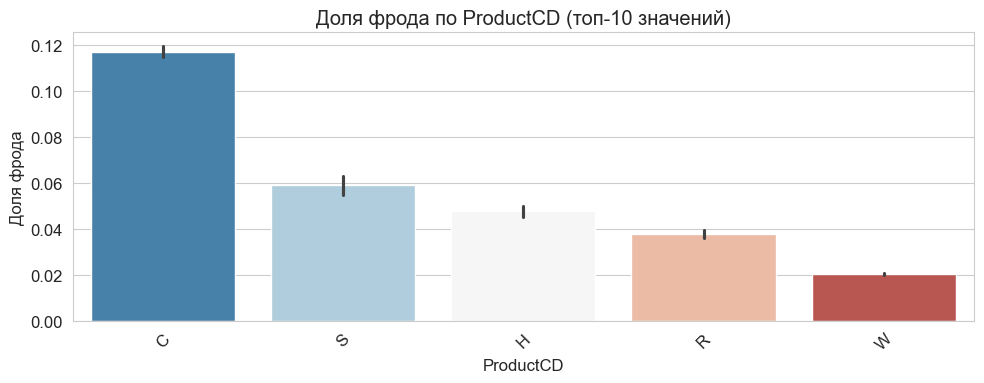

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/1191950433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y=target, data=df_filtered, order=order, palette="RdBu_r")


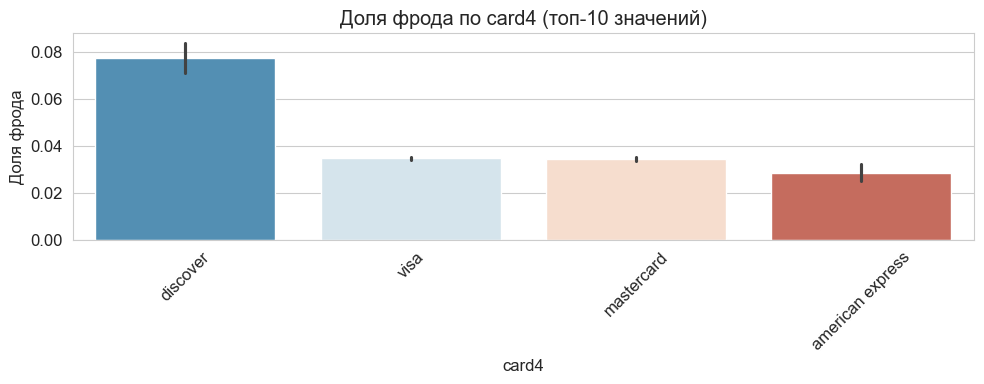

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/1191950433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y=target, data=df_filtered, order=order, palette="RdBu_r")


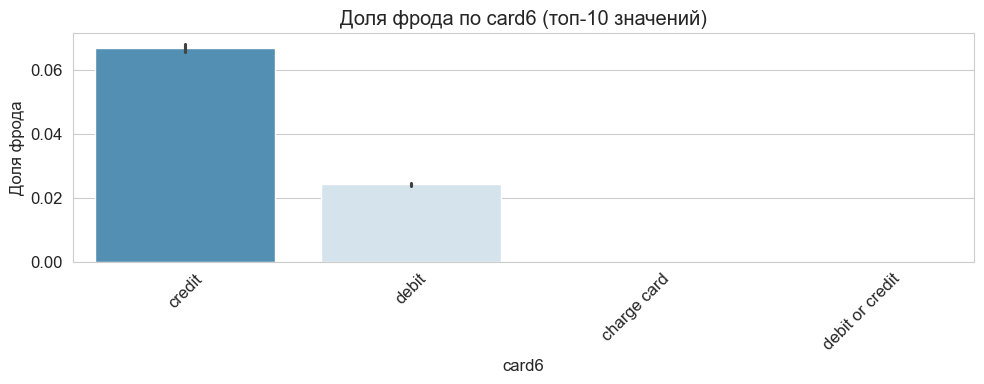

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/1191950433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y=target, data=df_filtered, order=order, palette="RdBu_r")


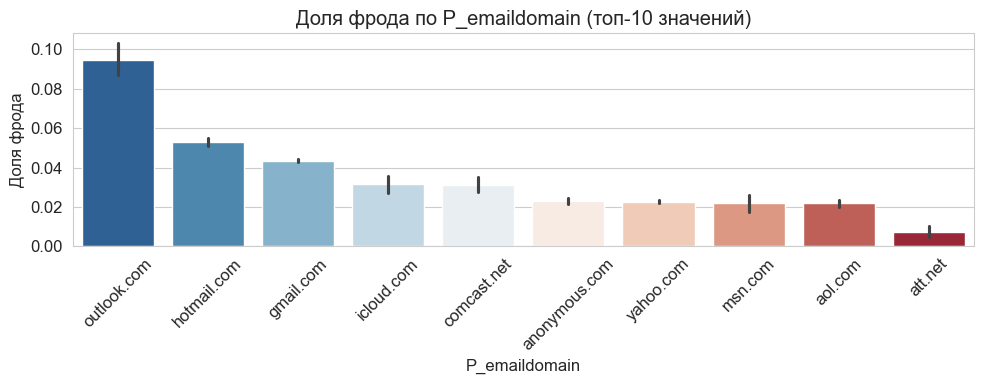

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/1191950433.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y=target, data=df_filtered, order=order, palette="RdBu_r")


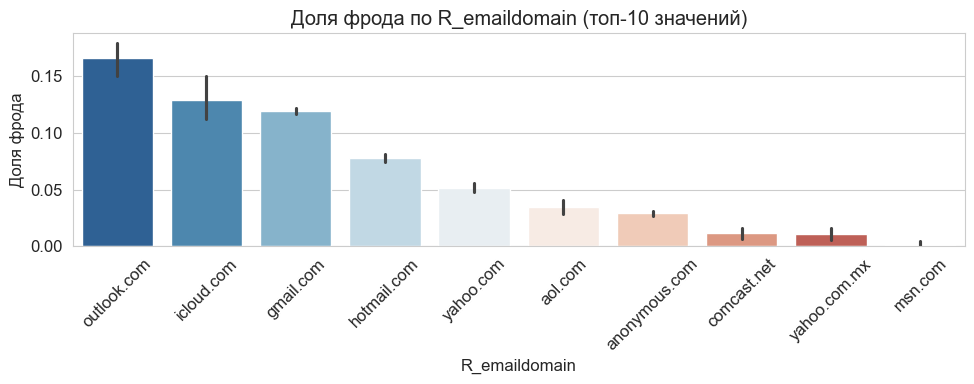

In [8]:
cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']

for col in cat_cols:
    if col in df.columns:
        top_cats = df[col].value_counts().head(10).index
        df_filtered = df[df[col].isin(top_cats)]
        
        plt.figure(figsize=(10,4))
        order = df_filtered.groupby(col)[target].mean().sort_values(ascending=False).index
        sns.barplot(x=col, y=target, data=df_filtered, order=order, palette="RdBu_r")
        plt.title(f"Доля фрода по {col} (топ-10 значений)")
        plt.xlabel(col)
        plt.ylabel("Доля фрода")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"fraud_rate_{col}.png", dpi=150)
        plt.show()

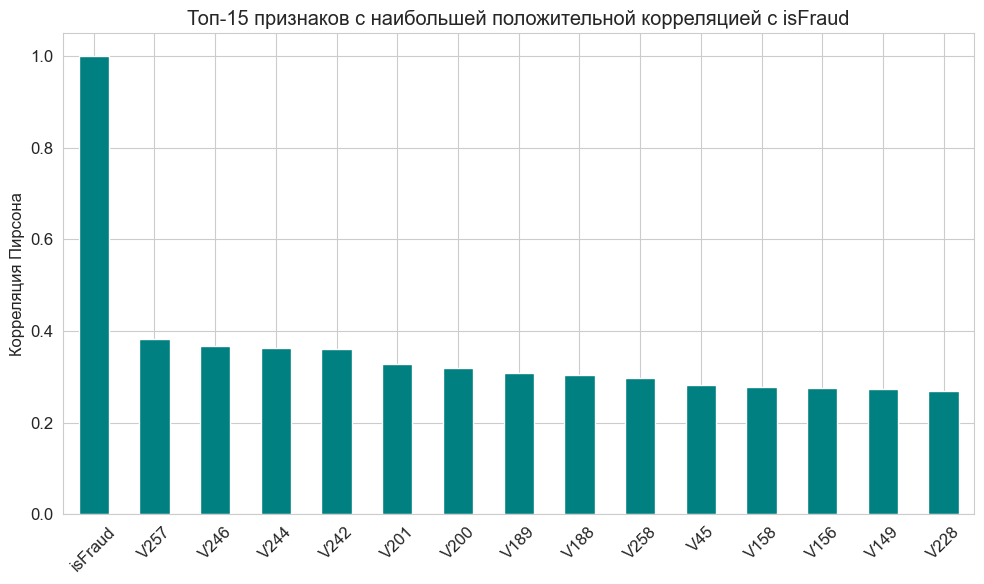

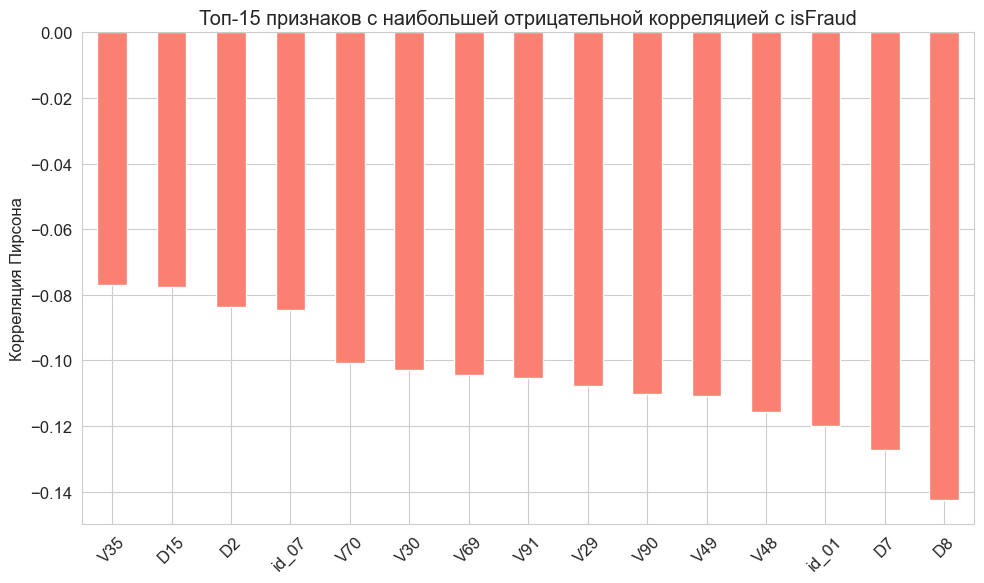

In [9]:
# Выбираем числовые колонки (включая те, что из identity)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Убираем TransactionID и другие ID-шники
ignore_cols = ['TransactionID', 'TransactionDT', 'day', 'hour']
numeric_cols = [c for c in numeric_cols if c not in ignore_cols]

# Корреляция с isFraud
corr_with_target = df[numeric_cols].corr()[target].sort_values(ascending=False)
top_corr = corr_with_target.head(15)
bottom_corr = corr_with_target.tail(15)

plt.figure(figsize=(10,6))
top_corr.plot(kind='bar', color='teal')
plt.title("Топ-15 признаков с наибольшей положительной корреляцией с isFraud")
plt.ylabel("Корреляция Пирсона")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_correlations_positive.png", dpi=150)
plt.show()

plt.figure(figsize=(10,6))
bottom_corr.plot(kind='bar', color='salmon')
plt.title("Топ-15 признаков с наибольшей отрицательной корреляцией с isFraud")
plt.ylabel("Корреляция Пирсона")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_correlations_negative.png", dpi=150)
plt.show()

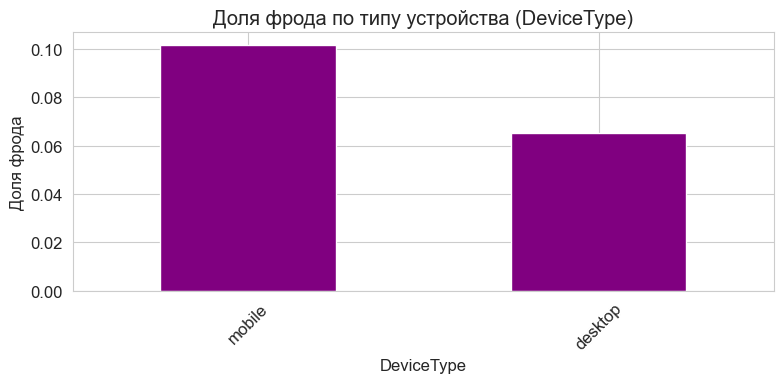

/var/folders/rd/wvzw9zxn5s33czj7mlmb27gr0000gn/T/ipykernel_9793/2217287037.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DeviceInfo', y=target, data=df_dev, order=order, palette="coolwarm")


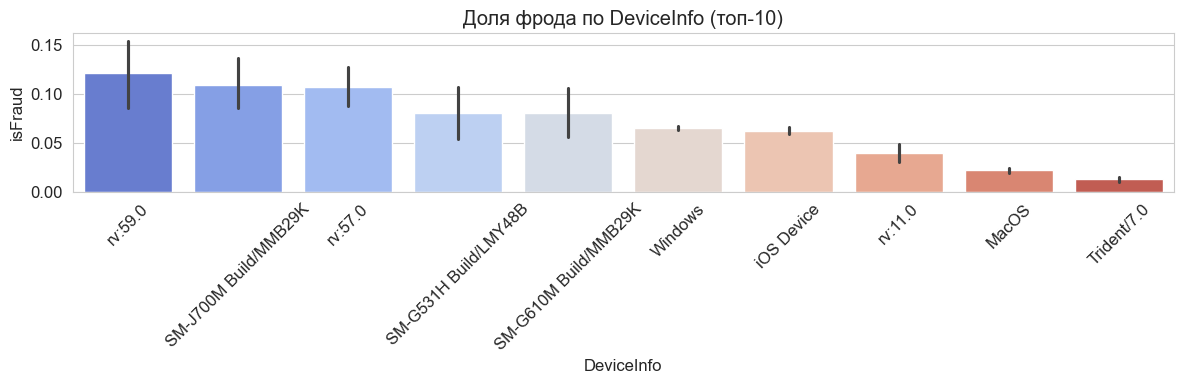

In [10]:
if 'DeviceType' in df.columns:
    plt.figure(figsize=(8,4))
    device_fraud = df.groupby('DeviceType')[target].mean().sort_values(ascending=False)
    device_fraud.plot(kind='bar', color='purple')
    plt.title("Доля фрода по типу устройства (DeviceType)")
    plt.ylabel("Доля фрода")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fraud_rate_by_device_type.png", dpi=150)
    plt.show()

if 'DeviceInfo' in df.columns:
    top_devices = df['DeviceInfo'].value_counts().head(10).index
    df_dev = df[df['DeviceInfo'].isin(top_devices)]
    plt.figure(figsize=(12,4))
    order = df_dev.groupby('DeviceInfo')[target].mean().sort_values(ascending=False).index
    sns.barplot(x='DeviceInfo', y=target, data=df_dev, order=order, palette="coolwarm")
    plt.title("Доля фрода по DeviceInfo (топ-10)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fraud_rate_by_device_info.png", dpi=150)
    plt.show()

Статистика доли фрода для карт, встречающихся более 1 раза:
count    10109.000000
mean         0.028422
std          0.115566
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: isFraud, dtype: float64


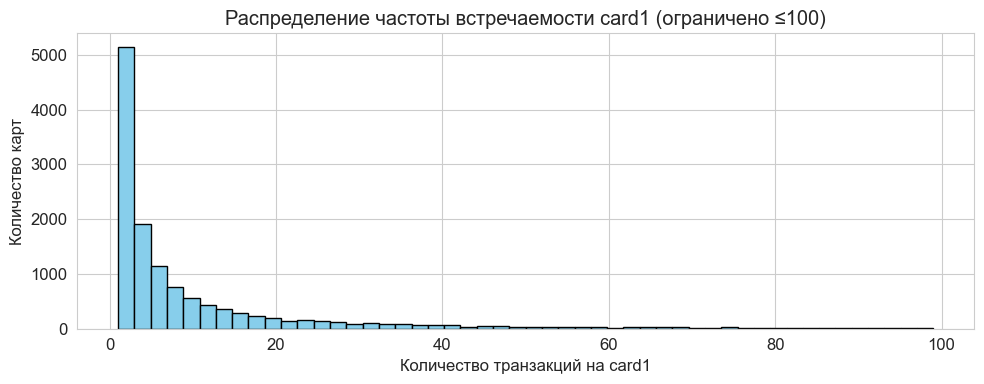

In [11]:
# Пример: анализ повторяющихся карт (card1) и их связь с фродом
if 'card1' in df.columns:
    card_counts = df['card1'].value_counts()
    common_cards = card_counts[card_counts > 1].index
    df_common = df[df['card1'].isin(common_cards)]
    fraud_by_card_freq = df_common.groupby('card1')[target].mean().describe()
    print("Статистика доли фрода для карт, встречающихся более 1 раза:")
    print(fraud_by_card_freq)
    
    # Гистограмма частоты карт
    plt.figure(figsize=(10,4))
    card_counts[card_counts < 100].hist(bins=50, color='skyblue', edgecolor='black')
    plt.title("Распределение частоты встречаемости card1 (ограничено ≤100)")
    plt.xlabel("Количество транзакций на card1")
    plt.ylabel("Количество карт")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "card1_frequency_distribution.png", dpi=150)
    plt.show()

In [12]:
from IPython.display import display, Markdown

display(Markdown("""
## Основные выводы EDA

- Сильный дисбаланс классов: доля фрода ~3.5%.
- Многие признаки имеют высокий процент пропусков (>80%), что потребует их удаления или специальной обработки.
- Распределение TransactionAmt для мошеннических транзакций смещено в сторону больших сумм (логарифмическая шкала показывает различия).
- Временной анализ: доля фрода меняется в зависимости от часа суток и со временем (возможен дрейф).
- Категориальные признаки (ProductCD, card4, P_emaildomain) имеют значительные различия в частоте фрода.
- Корреляционный анализ показывает несколько признаков с заметной связью с целевой переменной (например, id_12, id_15, V-признаки из transaction).
- DeviceType и DeviceInfo также показывают неоднородность по доле фрода.
"""))


## Основные выводы EDA

- Сильный дисбаланс классов: доля фрода ~3.5%.
- Многие признаки имеют высокий процент пропусков (>80%), что потребует их удаления или специальной обработки.
- Распределение TransactionAmt для мошеннических транзакций смещено в сторону больших сумм (логарифмическая шкала показывает различия).
- Временной анализ: доля фрода меняется в зависимости от часа суток и со временем (возможен дрейф).
- Категориальные признаки (ProductCD, card4, P_emaildomain) имеют значительные различия в частоте фрода.
- Корреляционный анализ показывает несколько признаков с заметной связью с целевой переменной (например, id_12, id_15, V-признаки из transaction).
- DeviceType и DeviceInfo также показывают неоднородность по доле фрода.
